In [38]:
# import necessary libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [3]:
# generate the initial data
np.random.seed(42)

n_samples = 1000
d = 2

mu_0 = np.array([-2.0, 0.0])
mu_1 = np.array([2.0, 0.0])

sigma = 1.0

# Initial labels
y = np.random.randint(0, 2, size=n_samples)

# Generate points according to their class
X = np.zeros((n_samples, d))

for i in range(n_samples):
    if y[i] == 0:
        X[i] = np.random.normal(mu_0, sigma, size=d)
    else:
        X[i] = np.random.normal(mu_1, sigma, size=d)

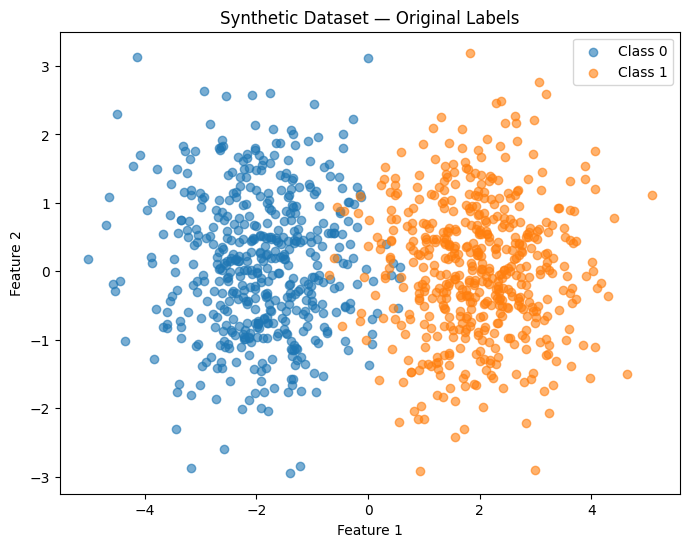

In [6]:
# visualize original labels

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    alpha=0.6
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    alpha=0.6
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Dataset — Original Labels")
plt.legend()
plt.show()

In [8]:
# construct KNN neighborhoods

k = 10

knn = NearestNeighbors(n_neighbors=k + 1)
knn.fit(X)

distances, indices = knn.kneighbors(X)

# Remove each point itself
neighbor_indices = indices[:, 1:]

In [14]:
# calculate average neighbor label

neighbor_label_mean = y[neighbor_indices].mean(axis=1)
neighbor_label_mean[:10]

array([0. , 1. , 0. , 0. , 0. , 0.8, 0. , 0. , 0. , 1. ])

In [17]:
# apply label reassignment rule
epsilon = 0.1

y_modified = y.copy()
ambiguous = np.abs(neighbor_label_mean - 0.5) < epsilon
y_modified[ambiguous] = 1 - y_modified[ambiguous]

n_flipped = np.sum(y_modified != y)

print("Number of flipped labels:", n_flipped)
print("Percentage flipped:", 100 * n_flipped / n_samples)

Number of flipped labels: 22
Percentage flipped: 2.2


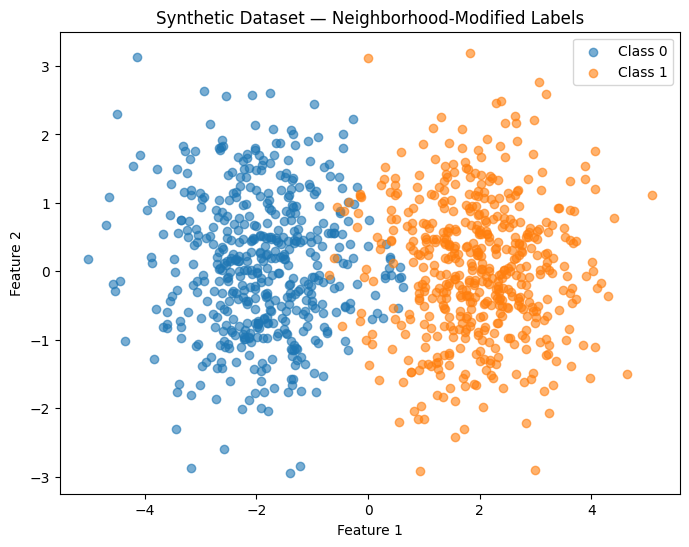

In [18]:
# visualize the initial data

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y_modified == 0, 0],
    X[y_modified == 0, 1],
    label="Class 0",
    alpha=0.6
)

plt.scatter(
    X[y_modified == 1, 0],
    X[y_modified == 1, 1],
    label="Class 1",
    alpha=0.6
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Dataset — Neighborhood-Modified Labels")
plt.legend()
plt.show()

In [19]:
# prepare the data for neural network training

# Central points
X_center = X

# Neighbor points for each sample
X_neighbors = X[neighbor_indices]

print("Central points shape:", X_center.shape)
print("Neighbor sets shape:", X_neighbors.shape)
print("Labels shape:", y_modified.shape)

Central points shape: (1000, 2)
Neighbor sets shape: (1000, 10, 2)
Labels shape: (1000,)


In [20]:
# check one example for verification

print("Central point:")
print(X_center[0])

print("\nIts 10 neighbors:")
print(X_neighbors[0])

print("\nOriginal label:")
print(y[0])

print("\nModified label:")
print(y_modified[0])

Central point:
[-1.65824402  1.87617084]

Its 10 neighbors:
[[-1.5865651   1.87679581]
 [-1.69116699  1.70221494]
 [-1.71022514  2.0754008 ]
 [-1.75061632  1.57745328]
 [-1.38084574  2.05749547]
 [-1.87732968  1.62467846]
 [-1.43101692  1.62839662]
 [-1.31810851  1.84670733]
 [-1.34145573  2.01020454]
 [-1.95639755  1.69505104]]

Original label:
0

Modified label:
0


In [21]:
# prepare training and testing data

X_center_train, X_center_test, X_neighbors_train, X_neighbors_test, y_train, y_test = train_test_split(
    X_center,
    X_neighbors,
    y_modified,
    test_size=0.2,
    random_state=42,
    stratify=y_modified
)

print("Training central points:", X_center_train.shape)
print("Training neighbor sets:", X_neighbors_train.shape)
print("Training labels:", y_train.shape)

print("Test central points:", X_center_test.shape)
print("Test neighbor sets:", X_neighbors_test.shape)
print("Test labels:", y_test.shape)

Training central points: (800, 2)
Training neighbor sets: (800, 10, 2)
Training labels: (800,)
Test central points: (200, 2)
Test neighbor sets: (200, 10, 2)
Test labels: (200,)


In [27]:
# convert data to PyTorch tensors
X_center_train = torch.tensor(X_center_train, dtype=torch.float32)
X_neighbors_train = torch.tensor(X_neighbors_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_center_test = torch.tensor(X_center_test, dtype=torch.float32)
X_neighbors_test = torch.tensor(X_neighbors_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_center_train.shape)
print(X_neighbors_train.shape)
print(y_train.shape)

torch.Size([800, 2])
torch.Size([800, 10, 2])
torch.Size([800])


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11312\1291757041.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_center_train = torch.tensor(X_center_train, dtype=torch.float32)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11312\1291757041.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_neighbors_train = torch.tensor(X_neighbors_train, dtype=torch.float32)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11312\1291757041.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
C:\Users\

In [28]:
# create dataloaders

train_dataset = TensorDataset(
    X_center_train,
    X_neighbors_train,
    y_train
)

test_dataset = TensorDataset(
    X_center_test,
    X_neighbors_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [29]:
# check and verify one batch of data

for center_batch, neighbors_batch, labels_batch in train_loader:
    print("Central batch:", center_batch.shape)
    print("Neighbor batch:", neighbors_batch.shape)
    print("Label batch:", labels_batch.shape)
    break

Central batch: torch.Size([32, 2])
Neighbor batch: torch.Size([32, 10, 2])
Label batch: torch.Size([32])


In [32]:
# implement deep sets

class DeepSets(nn.Module):

    def __init__(self):
        super().__init__()

        # phi: processes each neighbor independently
        self.phi = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32)
        )

        # rho: combines the pooled neighbors with the central point
        self.rho = nn.Sequential(
            nn.Linear(32 + 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, center, neighbors):

        # Process every neighbor
        neighbor_features = self.phi(neighbors)

        # Sum over the neighbor dimension
        pooled = neighbor_features.sum(dim=1)

        # Combine central point with pooled neighborhood
        combined = torch.cat([center, pooled], dim=1)

        # Predict
        output = self.rho(combined)

        return output.squeeze(1)

In [33]:
# create the model
model = DeepSets()

print(model)

DeepSets(
  (phi): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
  )
  (rho): Sequential(
    (0): Linear(in_features=34, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [34]:
# define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
# train the model
num_epochs = 50

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for center_batch, neighbors_batch, labels_batch in train_loader:

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(center_batch, neighbors_batch)

        # Calculate loss
        loss = criterion(outputs, labels_batch)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {average_loss:.4f}")

Epoch 10/50, Loss: 0.0632
Epoch 20/50, Loss: 0.0505
Epoch 30/50, Loss: 0.0457
Epoch 40/50, Loss: 0.0430
Epoch 50/50, Loss: 0.0407


In [36]:
# evaluate the model on 200 samples
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for center_batch, neighbors_batch, labels_batch in test_loader:

        outputs = model(center_batch, neighbors_batch)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        correct += (predictions == labels_batch).sum().item()
        total += labels_batch.size(0)

accuracy = correct / total

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 0.9700
Test Accuracy: 97.00%


In [37]:
# check permutation invariance
model.eval()

# Select one test sample
center = X_center_test[0:1]
neighbors = X_neighbors_test[0:1]

# Original prediction
with torch.no_grad():
    original_output = model(center, neighbors)
    original_probability = torch.sigmoid(original_output)

# Shuffle the neighbors
permutation = torch.randperm(neighbors.shape[1])
shuffled_neighbors = neighbors[:, permutation, :]

# Prediction after shuffling
with torch.no_grad():
    shuffled_output = model(center, shuffled_neighbors)
    shuffled_probability = torch.sigmoid(shuffled_output)

print("Original probability:", original_probability.item())
print("Shuffled probability:", shuffled_probability.item())
print(
    "Difference:",
    abs(original_probability.item() - shuffled_probability.item())
)

Original probability: 0.9999996423721313
Shuffled probability: 0.9999996423721313
Difference: 0.0


In [39]:
# metrics
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for center_batch, neighbors_batch, labels_batch in test_loader:

        outputs = model(center_batch, neighbors_batch)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        all_predictions.extend(predictions.numpy())
        all_labels.extend(labels_batch.numpy())

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Class 0", "Class 1"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))

Accuracy: 0.9700

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      0.97      0.97        98
     Class 1       0.97      0.97      0.97       102

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

Confusion Matrix:
[[95  3]
 [ 3 99]]


In [40]:
# test with one random permutation
model.eval()

center = X_center_test[0:1]
neighbors = X_neighbors_test[0:1]

with torch.no_grad():
    original_probability = torch.sigmoid(
        model(center, neighbors)
    ).item()

differences = []

for _ in range(10):

    permutation = torch.randperm(neighbors.shape[1])
    shuffled_neighbors = neighbors[:, permutation, :]

    with torch.no_grad():
        shuffled_probability = torch.sigmoid(
            model(center, shuffled_neighbors)
        ).item()

    differences.append(
        abs(original_probability - shuffled_probability)
    )

print("Original probability:", original_probability)
print("Maximum difference:", max(differences))
print("All differences:", differences)

Original probability: 0.9999996423721313
Maximum difference: 0.0
All differences: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
